In [1]:
import numpy as np
import pandas as pd
import torch
import re
import os

from scipy.special import comb, perm
from itertools import combinations, permutations

from tqdm import tqdm, trange
from pybloom_live import BloomFilter

import math
import sys
sys.path.append("../../..") ## 定位到utils目录
import datasets_HR

from torch.nn.utils.rnn import pad_sequence
from torch.nn.functional import one_hot
import torch
import networkx as nx
from pybloom_live import BloomFilter

from utils import utils, SubGDataset

import random
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

### GM12878 在chr8 (chr8:120000000-140000000 MYC)上的预测表现 
### chr8	127735434	127742951	MYC	7518	+

##### | 文献名称 | 估算中心位置，hg38 | 对应 5-kb bin | 功能解释 |
##### |---|---:|---|---|
##### | MYC `−556-kb` SE | `chr8:127,179,434` | `chr8:127,175,000-127,180,000` | 远端 upstream SE |
##### | MYC `−525-kb` ESE | `chr8:127,210,434` | `chr8:127,210,000-127,215,000` | 文献常用的 EBV-associated ESE |
##### | MYC `−428-kb` ESE | `chr8:127,307,434` | `chr8:127,305,000-127,310,000` | 具有较强 EBNA2、H3K27ac 和 MYC 接触信号 |
##### | MYC `−186-kb` enhancer | `chr8:127,549,434` | `chr8:127,545,000-127,550,000` | intermediate upstream enhancer |
##### | MYC `−168-kb` enhancer | `chr8:127,567,434` | `chr8:127,565,000-127,570,000` | intermediate upstream enhancer |
##### | MYC promoter | `chr8:127,735,434` | `chr8:127,735,000-127,740,000` | target promoter |

In [10]:
### 加载模型
test_chr = 'chr8'

model_dir = f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/HiPore-C_GM12878_5kb/HiPore-C_GM12878_5kb_test_{test_chr}'

model = torch.load(f'{model_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_Struc_r0.pt')

In [9]:
data_dir = '/data/xujs/Project/DeepLearning/MCIP/Results'
chrom_range_ = np.load(f"{data_dir}/preprocess_results/hg38.5kb.chrom_range.npy")
chrom_range = {}
for x in chrom_range_:
    chrom_range[x[0]] = np.array([int(x[1])-1, int(x[2])-1])

num = []
for chrom, v in chrom_range.items():
    num.append(v[1] - v[0])

node2chrom = np.load(f"{data_dir}/preprocess_results/hg38.5kb.node2chrom.npy", allow_pickle=True).item()
node2chrom = {(node-1):chrom for node, chrom in node2chrom.items()}

node_num = len(node2chrom)

df_chrom_region_node_num = pd.read_table('/data/xujs/Project/HiC2PoreC/code/SGMCI/dataset/hg38.5kb.chrom_region.node_num.txt')
chrom_region_dict = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/dataset/hg38.5kb.chrom_region_dict.npy', allow_pickle=True).item()

In [4]:
### MYC在chr8_120000000-140000000区间的节点id
MYC_node_id = np.int64((127735434 - 120000000) / 5000)
e1_node_id = np.int64((127210434 - 120000000) / 5000)
e2_node_id = np.int64((127307434 - 120000000) / 5000)
e3_node_id = np.int64((127549434 - 120000000) / 5000)
e4_node_id = np.int64((127567434 - 120000000) / 5000)

##### | MYC `−556-kb` SE | `chr8:127,179,434` | `chr8:127,175,000-127,180,000` | 远端 upstream SE |
##### | MYC `−525-kb` ESE | `chr8:127,210,434` | `chr8:127,210,000-127,215,000` | 文献常用的 EBV-associated ESE |
##### | MYC `−428-kb` ESE | `chr8:127,307,434` | `chr8:127,305,000-127,310,000` | 具有较强 EBNA2、H3K27ac 和 MYC 接触信号 |
##### | MYC `−186-kb` enhancer | `chr8:127,549,434` | `chr8:127,545,000-127,550,000` | intermediate upstream enhancer |
##### | MYC `−168-kb` enhancer | `chr8:127,567,434` | `chr8:127,565,000-127,570,000` | intermediate upstream enhancer |
##### | MYC promoter | `chr8:127,735,434` | `chr8:127,735,000-127,740,000` | target promoter |

In [5]:
import numpy as np
import pandas as pd
from torch.nn.utils.rnn import pad_sequence
from torch.nn.functional import one_hot
import torch
from torch_geometric.utils import is_undirected, to_undirected, negative_sampling, to_networkx
from torch_geometric.data import Data
import networkx as nx
import os

class BaseGraph(Data):
    def __init__(self, x, edge_index, edge_weight, subG_node, subG_label, subG_weight, mask):
        '''
        A general format for datasets.
        Args:
            x: node feature. For our used datasets, x is empty vector.
            subG_node: a matrix like [[0,2,3],[1,4,5],[6,7,-1]], whose i-th row contains the nodes in the i-th subgraph. -1 is for padding.
            subG_label: the target of subgraphs.
            mask: of shape (number of subgraphs), type torch.long. mask[i]=0,1,2 if i-th subgraph is in the training set, validation set and test set respectively. 
        '''
        super(BaseGraph, self).__init__(x=x,
                                        edge_index=edge_index,
                                        edge_attr=edge_weight,
                                        pos=subG_node,
                                        y=subG_label)
        self.subG_weight = subG_weight
        self.mask = mask
        self.to_undirected()

    def setDegreeFeature(self, mod=1):
        # use node degree as node features.
        adj = torch.sparse_coo_tensor(self.edge_index, self.edge_attr,
                                        (self.x.shape[0], self.x.shape[0]))
        degree = torch.sparse.sum(adj, dim=1).to_dense().to(torch.int64)
        degree = torch.div(degree, mod, rounding_mode='floor')
        degree = torch.unique(degree, return_inverse=True)[1]
        self.x = degree.reshape(self.x.shape[0], 1, -1)

    def setOneFeature(self):
        # use homogeneous node features.
        self.x = torch.ones((self.x.shape[0], 1, 1), dtype=torch.int64)

    def setNodeIdFeature(self):
        # use nodeid as node features.
        self.x = torch.arange(self.x.shape[0], dtype=torch.int64).reshape(
            self.x.shape[0], 1, -1)

    def get_split(self, split: str):
        tar_mask = {"train": 0, "valid": 1, "test": 2}[split]
        return self.x, self.edge_index, self.edge_attr, self.pos[
            self.mask == tar_mask], self.y[self.mask == tar_mask], self.subG_weight[self.mask == tar_mask]

    def get_data(self):
        return self.x, self.edge_index, self.edge_attr, self.pos, self.y, self.subG_weight

    def to_undirected(self):
        if not is_undirected(self.edge_index):
            self.edge_index, self.edge_attr = to_undirected(
                self.edge_index, self.edge_attr)

    def get_LPdataset(self, use_loop=False):
        # generate link prediction dataset for pretraining GNNs
        neg_edge = negative_sampling(self.edge_index)
        x = self.x
        ei = self.edge_index
        ea = self.edge_attr
        pos = torch.cat((self.edge_index, neg_edge), dim=1).t()
        y = torch.cat((torch.ones(ei.shape[1]),
                        torch.zeros(neg_edge.shape[1]))).to(ei.device)

        return x, ei, ea, pos, y

    def to(self, device):
        self.x = self.x.to(device)
        self.edge_index = self.edge_index.to(device)
        self.edge_attr = self.edge_attr.to(device)
        self.pos = self.pos.to(device)
        self.y = self.y.to(device)
        self.mask = self.mask.to(device)
        self.subG_weight = self.subG_weight.to(device)
        return self


def tfunc(ds, bs, shuffle=True, drop_last=True):
    return SubGDataset.ZGDataloader(ds,
                                    bs,
                                    z_fn=utils.MaxZOZ,
                                    shuffle=shuffle,
                                    drop_last=drop_last)

def loader_fn(ds, bs):
    return tfunc(ds, bs)

def tloader_fn(ds, bs):
    return tfunc(ds, bs, True, False)

In [12]:
dataset_name = 'HiPore-C_GM12878_5kb'
ns_mode = 'MIX'
genome = 'hg38'
binsize = '5kb'
batch_size = 512
chrom = 'chr8'
chrom_region = 'chr8_120000000-140000000'

model_dir = f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/{dataset_name}/{dataset_name}_test_{chrom}'
model = torch.load(f'{model_dir}/{dataset_name}_test_{chrom}_ND_MIX_Struc_r0.pt')

In [6]:
import numpy as np
from itertools import combinations, product


# ============================================================
# 1. Define target nodes
# ============================================================

node_names = np.array([
    "e1",
    "e2",
    "e3",
    "e4",
    "e5",
    "MYC"
])

target_node_ids = np.array([
    1442,
    1461,
    1509,
    1513,
    1532,
    1547
], dtype=np.int64)

MYC_node_id = 1547


# ============================================================
# 2. Parameters
# ============================================================

tolerance = 1

# At least 3 nodes in each MCI
min_nodes = 3

# If your trained model only supports 3-, 4-, and 5-way MCIs,
# set max_nodes = 5.
max_nodes = len(target_node_ids)

# True: every candidate must contain MYC
# False: generate all combinations without requiring MYC
require_myc = False


# ============================================================
# 3. Basic checks
# ============================================================

if len(node_names) != len(target_node_ids):
    raise ValueError(
        "node_names and target_node_ids must have the same length."
    )

if len(np.unique(target_node_ids)) != len(target_node_ids):
    raise ValueError(
        "target_node_ids must be unique."
    )

if MYC_node_id not in target_node_ids:
    raise ValueError(
        "MYC_node_id is not included in target_node_ids."
    )

if min_nodes < 3:
    raise ValueError(
        "min_nodes must be at least 3."
    )

if max_nodes > len(target_node_ids):
    raise ValueError(
        "max_nodes cannot exceed the total number of target nodes."
    )

myc_index = int(
    np.where(target_node_ids == MYC_node_id)[0][0]
)


# ============================================================
# 4. Generate candidate multi-way interactions
# ============================================================

def generate_mci_candidates(
    target_ids,
    names,
    myc_index,
    tolerance=1,
    min_nodes=3,
    max_nodes=None,
    require_myc=True
):
    """
    Generate candidate MCI combinations.

    Each selected canonical node ID can be replaced by:
        target_id - tolerance
        target_id
        target_id + tolerance

    Parameters
    ----------
    target_ids : np.ndarray
        Canonical node IDs.

    names : np.ndarray
        Node names, such as e1, e2, ..., MYC.

    myc_index : int
        Index of MYC in target_ids.

    tolerance : int
        Allowed node ID deviation.

    min_nodes : int
        Minimum number of nodes in a candidate.

    max_nodes : int or None
        Maximum number of nodes in a candidate.

    require_myc : bool
        Whether each candidate must contain MYC.

    Returns
    -------
    candidate_nodes : np.ndarray
        Padded candidate node IDs. Padding value is -1.

    candidate_orders : np.ndarray
        Number of nodes in each candidate.

    base_index_matrix : np.ndarray
        Indices of canonical nodes used in each candidate.

    candidate_labels : np.ndarray
        Canonical labels for each candidate.
    """

    target_ids = np.asarray(target_ids, dtype=np.int64)
    names = np.asarray(names)

    n_nodes = len(target_ids)

    if max_nodes is None:
        max_nodes = n_nodes

    candidate_nodes_list = []
    candidate_orders = []
    base_index_list = []
    candidate_labels = []

    # Avoid duplicate candidates, especially when target IDs are close
    seen = set()

    for k in range(min_nodes, max_nodes + 1):

        # Select canonical combinations, e.g.:
        # e1 + e2 + MYC
        # e1 + e3 + MYC
        # e1 + e2 + e3 + MYC
        for selected_indices in combinations(range(n_nodes), k):

            if require_myc and myc_index not in selected_indices:
                continue

            selected_indices = tuple(selected_indices)

            selected_names = names[list(selected_indices)]
            canonical_label = "+".join(selected_names)

            # Each selected node can be shifted by -1, 0, or +1
            offset_options = [
                range(-tolerance, tolerance + 1)
                for _ in selected_indices
            ]

            for offsets in product(*offset_options):

                candidate = np.array(
                    [
                        target_ids[idx] + offset
                        for idx, offset in zip(
                            selected_indices,
                            offsets
                        )
                    ],
                    dtype=np.int64
                )

                # Do not allow repeated node IDs
                if len(np.unique(candidate)) != k:
                    continue

                candidate_key = (
                    k,
                    tuple(candidate.tolist())
                )

                if candidate_key in seen:
                    continue

                seen.add(candidate_key)

                # Pad to the total number of target nodes
                padded_candidate = np.full(
                    n_nodes,
                    -1,
                    dtype=np.int64
                )

                padded_candidate[:k] = candidate

                padded_base_indices = np.full(
                    n_nodes,
                    -1,
                    dtype=np.int64
                )

                padded_base_indices[:k] = np.asarray(
                    selected_indices,
                    dtype=np.int64
                )

                candidate_nodes_list.append(
                    padded_candidate
                )

                candidate_orders.append(k)

                base_index_list.append(
                    padded_base_indices
                )

                candidate_labels.append(
                    canonical_label
                )

    candidate_nodes = np.vstack(
        candidate_nodes_list
    ).astype(np.int64)

    candidate_orders = np.asarray(
        candidate_orders,
        dtype=np.int64
    )

    base_index_matrix = np.vstack(
        base_index_list
    ).astype(np.int64)

    candidate_labels = np.asarray(
        candidate_labels,
        dtype="<U100"
    )

    return (
        candidate_nodes,
        candidate_orders,
        base_index_matrix,
        candidate_labels
    )


# ============================================================
# 5. Generate candidates
# ============================================================

(
    candidate_nodes,
    candidate_orders,
    base_index_matrix,
    candidate_labels
) = generate_mci_candidates(
    target_ids=target_node_ids,
    names=node_names,
    myc_index=myc_index,
    tolerance=tolerance,
    min_nodes=min_nodes,
    max_nodes=max_nodes,
    require_myc=require_myc
)


# ============================================================
# 6. Print summary
# ============================================================

print("Target nodes:")
for name, node_id in zip(node_names, target_node_ids):
    print(f"  {name}: {node_id}")

print("\nMYC node ID:", MYC_node_id)
print("Tolerance:", tolerance)
print("Minimum MCI order:", min_nodes)
print("Maximum MCI order:", max_nodes)
print("Require MYC:", require_myc)

print("\nTotal candidates:", len(candidate_nodes))

for k in range(min_nodes, max_nodes + 1):
    count = np.sum(candidate_orders == k)
    print(f"{k}-way candidates: {count}")


# ============================================================
# 7. Print several candidate examples
# ============================================================

print("\nFirst candidate examples:")

for i in range(min(20, len(candidate_nodes))):

    k = int(candidate_orders[i])

    nodes = candidate_nodes[i, :k]

    base_indices = base_index_matrix[i, :k]

    base_names = node_names[base_indices]

    print(
        f"Index {i:4d} | "
        f"{candidate_labels[i]:18s} | "
        f"nodes = {nodes.tolist()} | "
        f"canonical = {base_names.tolist()}"
    )


# # ============================================================
# # 8. Save NumPy arrays
# # ============================================================

# np.save(
#     "myc_mci_candidate_nodes.npy",
#     candidate_nodes
# )

# np.save(
#     "myc_mci_candidate_orders.npy",
#     candidate_orders
# )

# np.save(
#     "myc_mci_base_node_indices.npy",
#     base_index_matrix
# )

# np.save(
#     "myc_mci_candidate_labels.npy",
#     candidate_labels
# )

# print("\nSaved files:")
# print("  myc_mci_candidate_nodes.npy")
# print("  myc_mci_candidate_orders.npy")
# print("  myc_mci_base_node_indices.npy")
# print("  myc_mci_candidate_labels.npy")

Target nodes:
  e1: 1442
  e2: 1461
  e3: 1509
  e4: 1513
  e5: 1532
  MYC: 1547

MYC node ID: 1547
Tolerance: 1
Minimum MCI order: 3
Maximum MCI order: 6
Require MYC: False

Total candidates: 3942
3-way candidates: 540
4-way candidates: 1215
5-way candidates: 1458
6-way candidates: 729

First candidate examples:
Index    0 | e1+e2+e3           | nodes = [1441, 1460, 1508] | canonical = ['e1', 'e2', 'e3']
Index    1 | e1+e2+e3           | nodes = [1441, 1460, 1509] | canonical = ['e1', 'e2', 'e3']
Index    2 | e1+e2+e3           | nodes = [1441, 1460, 1510] | canonical = ['e1', 'e2', 'e3']
Index    3 | e1+e2+e3           | nodes = [1441, 1461, 1508] | canonical = ['e1', 'e2', 'e3']
Index    4 | e1+e2+e3           | nodes = [1441, 1461, 1509] | canonical = ['e1', 'e2', 'e3']
Index    5 | e1+e2+e3           | nodes = [1441, 1461, 1510] | canonical = ['e1', 'e2', 'e3']
Index    6 | e1+e2+e3           | nodes = [1441, 1462, 1508] | canonical = ['e1', 'e2', 'e3']
Index    7 | e1+e2+e3      

In [13]:
#### 预测chr8 MYC unknown MCIs

# baseG = datasets_HR.load_dataset(dataset_name, ns_mode, chrom_region, 'ND',  genome, binsize)


# sub_G = np.load(f'./chrom_region_Unobserved_MCI/{chrom_region}_Unobserved_3way_MCI.npy')

# sub_G = candidate_nodes[candidate_orders == 4][:, :4]
sub_G = candidate_nodes
sub_G_label = torch.zeros(sub_G.shape[0], dtype=torch.int64)
sub_G_weight = torch.ones(sub_G.shape[0], dtype=torch.int64)
mask = torch.zeros(sub_G.shape[0], dtype=torch.int64)
pos = torch.from_numpy(sub_G)

rawedge = nx.read_edgelist(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/dataset/{dataset_name}/{chrom}/{chrom_region}/edge_list.txt', nodetype=int, data=(('weight',float),)).edges(data=True)
edge_index = torch.tensor([[int(i[0]), int(i[1])] for i in rawedge]).t()
edge_weight = torch.tensor([i[2]['weight'] for i in rawedge])

## 需要指定节点数量
df_node_num = pd.read_table(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/dataset/{genome}.{binsize}.node_num.txt')
node_num_dict = dict(zip(df_chrom_region_node_num['chrom_region'], df_chrom_region_node_num['chrom_region_node_num']))
# chrom_symbol = name.split('_')[-2]
chrom_node_num = node_num_dict[chrom_region] ##低分辨率下不分染色体，而是全基因组;高分辨率下是分染色体20Mb区间
num_node = max([torch.max(pos), torch.max(edge_index)]) + 1
num_node = max([num_node, chrom_node_num])
x = torch.empty((num_node, 1, 0))

## baseG
baseG = BaseGraph(x, edge_index, edge_weight, pos, sub_G_label, sub_G_weight, mask)
baseG.setNodeIdFeature()
device = torch.device(f'cuda:{0}' if torch.cuda.is_available() else 'cpu')
baseG.to(device)
baseG_dataset = SubGDataset.GDataset(*baseG.get_data())
baseG_loader = tloader_fn(baseG_dataset, batch_size)

## predict
subG_list = []
weight_list = []
y_list = []
pred_list = []

model.eval()
with torch.no_grad():
    for batch in tqdm(baseG_loader):
        pred, _ = model(*batch[:-2])
        
        subG_list.append([x[x>-1] for x in batch[3]])
        weight_list.append(batch[-1])
        y_list.append(batch[-2])
        pred_list.append(pred)

subG_list2 = []
for subG in subG_list:
    for x in subG:
        subG_list2.append(x.detach().cpu().numpy())
weight_list = torch.cat(weight_list).detach().cpu().numpy()
y_list = torch.cat(y_list).detach().cpu().numpy()
pred_list = torch.cat(pred_list).detach().cpu().numpy()

100%|██████████| 8/8 [00:00<00:00, 14.91it/s]


In [14]:
pred_list[pred_list > 0.5]

array([0.6421513 , 0.9682549 , 0.9390803 , 0.61399364, 0.98641473,
       0.97816086, 0.8404494 , 0.5404035 , 0.80869156, 0.8938157 ,
       0.95793283, 0.6983598 , 0.9651871 , 0.9645789 , 0.8468132 ,
       0.78804725, 0.6581388 , 0.6965885 , 0.8037649 , 0.6176019 ,
       0.54223764, 0.7046345 , 0.799061  , 0.8790011 , 0.68488085,
       0.74816954, 0.71894395, 0.6663178 , 0.9767131 , 0.82632154,
       0.7641899 , 0.96147525, 0.9898739 , 0.614051  , 0.9596871 ,
       0.80394804, 0.93609244], dtype=float32)

In [102]:
#### 预测chr8 known MCIs

baseG = datasets_HR.load_dataset(dataset_name, ns_mode, chrom_region, 'ND',  genome, binsize)
baseG.setNodeIdFeature()
device = torch.device(f'cuda:{0}' if torch.cuda.is_available() else 'cpu')
baseG.to(device)
baseG_dataset = SubGDataset.GDataset(*baseG.get_data())
baseG_loader = tloader_fn(baseG_dataset, batch_size)

## predict
subG_list = []
weight_list = []
y_list = []
pred_list = []

model.eval()
with torch.no_grad():
    for batch in tqdm(baseG_loader):
        pred, _ = model(*batch[:-2])
        
        subG_list.append([x[x>-1] for x in batch[3]])
        weight_list.append(batch[-1])
        y_list.append(batch[-2])
        pred_list.append(pred)

subG_list2 = []
for subG in subG_list:
    for x in subG:
        subG_list2.append(x.detach().cpu().numpy())
weight_list = torch.cat(weight_list).detach().cpu().numpy()
y_list = torch.cat(y_list).detach().cpu().numpy()
pred_list = torch.cat(pred_list).detach().cpu().numpy()

  0%|          | 0/33 [00:00<?, ?it/s]

100%|██████████| 33/33 [00:02<00:00, 11.61it/s]


In [174]:
import numpy as np

# 目标节点 ID
e_ids = {
    "e1": 1442,
    "e2": 1461,
    "e3": 1509,
    "e4": 1513,
    "e5": 1532,
}

MYC_node_id = 1547


# 允许的 ID 误差
tolerance = 5


def contains_near_id(nodes, target_id, tolerance=1):
    """
    判断 nodes 中是否存在与 target_id 相差不超过 tolerance 的节点。
    """
    nodes = np.asarray(nodes)
    return np.any(np.abs(nodes - target_id) <= tolerance)


matched_indices = []
matched_details = []

for idx, subgraph in enumerate(subG_list2):
    # 判断是否包含 MYC 节点或其邻近 ID
    contains_myc = contains_near_id(
        subgraph,
        MYC_node_id,
        tolerance
    )

    # 找到匹配的 e_id
    matched_e_ids = []

    for e_name, e_node_id in e_ids.items():
        if contains_near_id(
            subgraph,
            e_node_id,
            tolerance
        ):
            matched_e_ids.append(e_name)

    # 必须包含 MYC，且至少包含两个 e_id
    if contains_myc and len(matched_e_ids) >= 2:
        matched_indices.append(idx)

        matched_details.append({
            "index": idx,
            "subgraph": subgraph,
            "matched_e_ids": matched_e_ids,
            "contains_myc": True,
        })

print("符合条件的索引：", matched_indices)
print("详细匹配结果：")

for item in matched_details:
    print(item)

符合条件的索引： [1241, 1355, 10190, 11390, 12056, 12821, 13953, 14684, 14880]
详细匹配结果：
{'index': 1241, 'subgraph': array([1436, 1443, 1466, 1531, 1543]), 'matched_e_ids': ['e1', 'e2', 'e3'], 'contains_myc': True}
{'index': 1355, 'subgraph': array([1436, 1441, 1545, 1583, 1586, 1616, 1680]), 'matched_e_ids': ['e1', 'e2'], 'contains_myc': True}
{'index': 10190, 'subgraph': array([1314, 1437, 1452, 1546, 1599, 1615, 1634, 1656]), 'matched_e_ids': ['e1', 'e2'], 'contains_myc': True}
{'index': 11390, 'subgraph': array([  73, 1500, 1509, 1549, 1551, 1559, 2085]), 'matched_e_ids': ['e4', 'e5'], 'contains_myc': True}
{'index': 12056, 'subgraph': array([1500, 1509, 1549, 1551, 1559, 1666, 2085]), 'matched_e_ids': ['e4', 'e5'], 'contains_myc': True}
{'index': 12821, 'subgraph': array([1429, 1449, 1451, 1510, 1549, 1608]), 'matched_e_ids': ['e4', 'e5'], 'contains_myc': True}
{'index': 13953, 'subgraph': array([1314, 1437, 1452, 1546, 1599, 1615, 1656, 2248]), 'matched_e_ids': ['e1', 'e2'], 'contains_myc'

In [180]:
for item in matched_details:
    x = item['index']
    subG = subG_list2[x]
    weight = weight_list[x]
    y = y_list[x]
    pred = pred_list[x]
    print(f'For {subG}, Weight {weight}, y: {y}, pred: {pred}')

For [1436 1443 1466 1531 1543], Weight 2, y: 0.0, pred: [1.5317083e-23]
For [1436 1441 1545 1583 1586 1616 1680], Weight 2, y: 0.0, pred: [7.739289e-16]
For [1314 1437 1452 1546 1599 1615 1634 1656], Weight 2, y: 1.0, pred: [4.970413e-25]
For [  73 1500 1509 1549 1551 1559 2085], Weight 2, y: 0.0, pred: [0.6987361]
For [1500 1509 1549 1551 1559 1666 2085], Weight 2, y: 1.0, pred: [0.27594474]
For [1429 1449 1451 1510 1549 1608], Weight 2, y: 0.0, pred: [1.7231689e-18]
For [1314 1437 1452 1546 1599 1615 1656 2248], Weight 2, y: 0.0, pred: [1.2952243e-05]
For [1417 1440 1547 2171], Weight 2, y: 1.0, pred: [0.9999999]
For [1417 1440 1547 1776], Weight 2, y: 0.0, pred: [0.99771285]


In [3]:
import numpy as np
import pandas as pd
import cooler

import matplotlib.pyplot as plt
from tqdm import tqdm, trange

from itertools import combinations

from genomic_regions import as_region
 
import math
import re
import matplotlib.pyplot as plt
import networkx as nx
import random

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [4]:
## FAN-C track visualization.

import numpy as np
import pandas as pd
import datatable as dt
import gc

import seaborn as sns

import matplotlib.pyplot as plt
sns.set_color_codes("pastel")
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.patches import Arc, Polygon, Rectangle
from intervaltree import Interval, IntervalTree
import pybedtools
import tempfile
import sys, os
import math

import fanc
import fanc.plotting as fancplot
from genomic_regions import GenomicRegion, as_region

def get_region(region):
    chrom, pos = region.split(':')
    start, end = pos.split('-')
    return chrom, int(start), int(end)

class InputError(Exception):
    "Exception raised for errors in the input."
    pass

def process_link_file(link_file, plot_regions):

    if plot_regions is None:
        file_to_open = link_file
    else:
        plot_regions_adapted = [(chrom, 0, int(3e8)) for chrom, __, __ in plot_regions]
        file_to_open = temp_file_from_intersect(link_file, plot_regions_adapted)

    interval_tree = {}
    line_number = 0
    with open(file_to_open, 'r') as f:
        for line in f:
            line_number += 1
            if line.startswith('#'):
                continue
            try:
                chrom1, start1, end1, chrom2, start2, end2 = line.strip().split('\t')[:6]
            except Exception as detail:
                raise InputError('File not valid. The file format should be'
                                f'chrom1 start1 end1 chrom2 start2 end2\n Error: {detail}\n'
                                f' in line\n {line}')
            if chrom1 != chrom2:
                continue

            start1, end1, start2, end2 = int(start1), int(end1), int(start2), int(end2)
            
            assert start1 <= end1, f'Error in line #{line_number}, end1 larger than start1 in {line}'
            assert start2 <= end2, f'Error in line #{line_number}, end2 larger than start2 in {line}'

            if chrom1 not in interval_tree:
                interval_tree[chrom1] = IntervalTree()
            
            if start2 < start1:
                start1, start2 = start2, start1
                end1, end2 = end2, end1
            
            mid1 = (start1 + end1) / 2
            mid2 = (start2 + end2) / 2
            interval_tree[chrom1].add(Interval(mid1, mid2, [start1, end1, start2, end2]))
    return interval_tree

def temp_file_from_intersect(filename, plot_regions=None, around_region=0):
    """
    intersect filename with the plot_regions +/- around_region.
    :param filename: string file name.
    :param plot_regions: a list of tuple [(chrom1, start1, end1), (chrom2, start2, end2)]
    :param around_region: integer with the bo to extend the plot_region.
    :return: tmoporary file with the intersection.
    """
    file_to_open = filename
    if plot_regions is not None:
        original_file = pybedtools.BedTool(filename)
        plot_regions_ext = [(chrom, int(max(1, start-around_region)), int(end+around_region)) for chrom, start, end in plot_regions]
        ### overlap both version of chromosome name (with/without chr)
        plot_regions_as_bed = '\n'.join([f'{chrom}\t{start}\t{end}\n{change_chrom_names(chrom)}\t{start}\t{end}' for chrom, start, end in plot_regions_ext])
        regions = pybedtools.BedTool(plot_regions_as_bed, from_string=True)
        temporary_file = tempfile.NamedTemporaryFile(delete=False)
        sys.stderr = open(temporary_file.name, 'w')

        try:
            file_to_open = original_file.intersect(regions, wa=True, u=True).fn
            # print(file_to_open)
        except pybedtools.helpers.BEDToolsError:
            file_to_open = filename
            # print(f'===>{file_to_open}')
        sys.stderr.close()
        sys.stderr = sys.__stderr__
        with open(temporary_file.name, 'r') as f:
            temd_std_error = f.readlines()
        os.remove(temporary_file.name)
        error_lines = [line for line in temd_std_error if 'error' in line.lower()]
        if len(error_lines) >0:
            error_lines_printable = '\n'.join(error_lines)
            sys.stderr.write('Bedtools intersect raised an error:\n'
                             f"{error_lines_printable}\n"
                             "Will not use bedtools.\n")
            file_to_open = filename
    return file_to_open


def change_chrom_names(chrom):
    if chrom.startswith('chr'):
        chrom = chrom[3:]
    else:
        chrom = 'chr' + chrom

    return chrom


def plot_arcs(ax, interval, color='#C5479B', compact_arcs_level=1):
    width = interval.end - interval.begin
    if compact_arcs_level == 1: ## the height is propotional to the square root of the distance.
        half_height = np.sqrt(width)
    elif compact_arcs_level == 2:  ## the height is the same for all distance.
        half_height = 1000
    else:
        half_height = width
    center = interval.end - width / 2

    ax.add_patch(Arc((center, 0), width, 2*half_height, 
                      0, 0, 180, color=color, alpha=1,
                      linewidth=1, ls='solid'))


def check_chrom_str_bytes(iteratable_obj, p_obj):

    def to_string(s):
        """
        This takes care of python2/3 differences
        """
        if isinstance(s, str):
            return s
        if isinstance(s, bytes):
            assert(sys.version_info[0] != 2)
        #        if sys.version_info[0] == 2:
        #            return str(s)
            return s.decode('ascii')
        if isinstance(s, list):
            return [to_string(x) for x in s]
        return s

    def to_bytes(s):
        """
        Like toString, but for functions requiring bytes in python3
        """
        assert(sys.version_info[0] != 2)
    #    if sys.version_info[0] == 2:
    #        return s
        if isinstance(s, bytes):
            return s
        if isinstance(s, str):
            return bytes(s, 'ascii')
        if isinstance(s, list):
            return [to_bytes(x) for x in s]
        return s
    # determine type
    if isinstance(p_obj, list) and len(p_obj) > 0:
        type_ = type(p_obj[0])
    else:
        type_ = type(p_obj)
    if not isinstance(type(next(iter(iteratable_obj))), type_):
        if type(next(iter(iteratable_obj))) is str:
            p_obj = to_string(p_obj)
        elif type(next(iter(iteratable_obj))) in [bytes, np.bytes_]:
            p_obj = to_bytes(p_obj)
    return p_obj


def plot_loop(ax, interval_tree, region_chrom, region_start, region_end, ylabel=''):
    region_chrom = check_chrom_str_bytes(interval_tree, region_chrom)
    arcs_in_region = sorted(interval_tree[region_chrom][region_start:region_end])

    ## get ylim.
    if arcs_in_region:
        yvalues = [np.sqrt(interval.end - interval.begin) for interval in arcs_in_region ]
        ymax = math.ceil(np.percentile(yvalues, 90) / 100 + 1) * 100

        for idx, interval in enumerate(arcs_in_region):
            if interval.begin < region_start and interval.end >region_end:
                continue
            plot_arcs(ax, interval, compact_arcs_level=1)
    else:
        ymax = 0

    ax.set_xlim([region_start, region_end])
    Xtick = list( np.linspace(region_start, region_end, 5 ,endpoint=True) )
    Xtick_label = [ "%.3f"%(i/10**6) for i in Xtick ]
    ax.set_xticks(Xtick)
    # ax.set_ylim([ymax, 0])
    ax.set_ylim([0, ymax])
    ax.set_yticks([])
    ax.set_ylabel(ylabel)
    ## remove frame border.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(False)

def FancTrackLinePlot(filename, color, label, fill=True, ylabel=None, ylim=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.LinePlot(track, fill=fill, style='mid', colors=[color], labels=[label], ylabel=ylabel, ylim=ylim, n_yticks=2, ax=ax)
    return hp

def FancTrackBarPlot(filename, color, label, ylabel=None, ylim=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.BarPlot(track, style='step', colors=[color], labels=[label], ylabel=ylabel, ylim=ylim, n_yticks=2, ax=ax)
    return hp


def FancTrackRegionPlot(filename, color, ylabel=None, ax=None):
    track = fanc.load(filename)
    hp = fancplot.GenomicFeaturePlot(track, color=color, ylabel=ylabel, ax=ax)
    return hp

/data/xujs/miniconda3/lib/python3.7/site-packages/fanc/compatibility/juicer.py:797: UserWarning: Cannot find normalisation vector for chromosome: M, normalisation: KR, resolution: 5000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will return NaN instead.
  res=resolution, unit=unit
/data/xujs/miniconda3/lib/python3.7/site-packages/fanc/compatibility/juicer.py:684: UserWarning: Cannot find an expected value scaling factor for M, setting to 0.
  "for {}, setting to 0.".format(chromosome))
/data/xujs/miniconda3/lib/python3.7/site-packages/fanc/compatibility/juicer.py:686: RuntimeWarning: divide by zero encountered in true_divide
  return np.array(vectors[resolution]) / sf
/data/xujs/miniconda3/lib/python3.7/site-packages/fanc/compatibility/juicer.py:797: UserWarning: Cannot find normalisation vector for chromosome: M, normalisation: KR, resolution: 5000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will ret

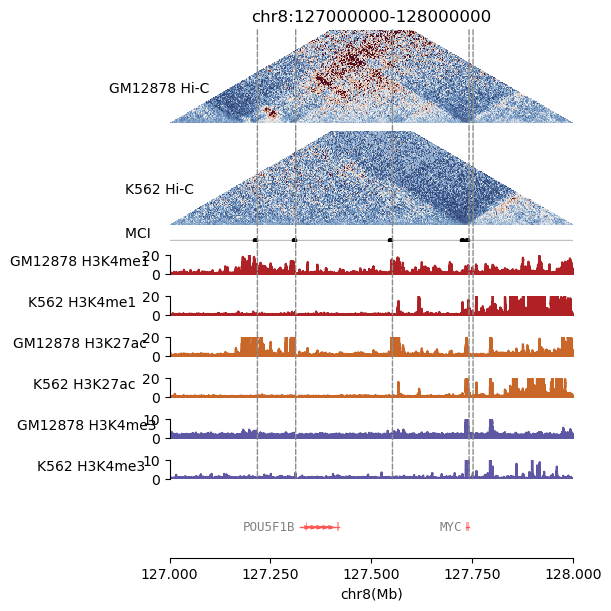

In [6]:
#### 可视化 MYC locus

## 1. GM12878 Hi-C heatmap
## 2. K562 Hi-C heatmap
## 3. predicted MCI.
## 4. GM12878 H3K4me1
## 5. K562 H3K4me1
## 6. GM12878 H3K27ac
## 7. K562 H3K27ac
## 8. GM12878 H3K4me3
## 9. K562 H3K4me3

# 1264	1278	1303	39	chr6_6320000-6325000	chr6_6390000-6395000	chr6_6515000-6520000	0.527711	0.035552375	F13A1		

# node_regions = ['chr21_44485000-44490000',	'chr21_44935000-44940000',	'chr21_45145000-45150000']

##### | MYC `−556-kb` SE | `chr8:127,179,434` | `chr8:127,175,000-127,180,000` | 远端 upstream SE |
##### | MYC `−525-kb` ESE | `chr8:127,210,434` | `chr8:127,210,000-127,215,000` | 文献常用的 EBV-associated ESE |
##### | MYC `−428-kb` ESE | `chr8:127,307,434` | `chr8:127,305,000-127,310,000` | 具有较强 EBNA2、H3K27ac 和 MYC 接触信号 |
##### | MYC `−186-kb` enhancer | `chr8:127,549,434` | `chr8:127,545,000-127,550,000` | intermediate upstream enhancer |
##### | MYC `−168-kb` enhancer | `chr8:127,567,434` | `chr8:127,565,000-127,570,000` | intermediate upstream enhancer |
##### | MYC promoter | `chr8:127,735,434` | `chr8:127,735,000-127,740,000` | target promoter |

node_regions = ['chr8:127210000-127215000',	'chr8:127305000-127310000', 'chr8:127545000-127550000', 'chr8:127700000-127750000', 'chr8:127735000-127740000']

region = as_region('chr8:127000000-128000000')
hic_region = f'{region.chromosome.replace("chr", "")}:{(region.start/1000000):.2f}mb-{(region.end/1000000):.2f}mb'  ## hic_region = '1:100mb-230mb'
fanc_region = f'{region.chromosome}:{(region.start/1000000):.2f}mb-{(region.end/1000000):.2f}mb'

def convert_chrom_region(region):
    chrom, start, end = re.split(':|-|_', region)
    return f'{chrom}:{start}-{end}'

fig, axes = plt.subplots(10, 1, figsize=(6, 6), constrained_layout=True,
                        gridspec_kw={'height_ratios': [0.3, 0.3, 0.01, 
                                                        0.06, 0.06, 0.06, 0.06, 0.06, 0.06,
                                                        0.2]})
axes = axes.flatten()

## set heatmap color.
cmap_classic = LinearSegmentedColormap.from_list('normal', [(1, 1, 1), (1, 0, 0)], N=1000)  # white -> red
cmap_diff = LinearSegmentedColormap.from_list('normal', [(0,0,1), (1,1,1), (1,0,0)], N=1000)  ## colormap: blue -> red
cmap_oe = LinearSegmentedColormap.from_list('normal', ['#1f2d5f', '#6d93bf', '#edf0f2', '#dba786', '#520c1c'], N=1000) 

## 1. GM12878 Hi-C OE heatmap
hic_file_dir = '/data/xujs/Project/HiPoreC_Promoter_Result/Result/2022-09-27_HiPoreC_to_cool_hic_files'
gm12878_hic_filename = f'{hic_file_dir}/GM12878.Merge.HiPoreC.hic@5kb'
gm12878_hic = fanc.load(gm12878_hic_filename)
# HiC_plot = fancplot.TriangularMatrixPlot(hic, vmin=0, vmax=10000, max_dist=region.end - region.start, colormap=cmap_diff, show_colorbar=True, ax=axes[0])
HiC_plot = fancplot.TriangularMatrixPlot(gm12878_hic, vmin=0, vmax=3, oe=True, max_dist='0.8mb', colormap=cmap_oe, show_colorbar=False, ax=axes[0])
HiC_plot.plot(hic_region)
axes[0].set_ylabel('GM12878 Hi-C', rotation=0, x=-0.1, y=0.3)

## 2. K562 Hi-C OE heatmap
k562_hic_filename = f'{hic_file_dir}/K562.Merge.HiPoreC.hic@5kb'
k562_hic = fanc.load(k562_hic_filename)
HiC_plot = fancplot.TriangularMatrixPlot(k562_hic, vmin=0, vmax=3, oe=True, max_dist='0.8mb', colormap=cmap_oe, show_colorbar=False, ax=axes[1])
HiC_plot.plot(hic_region)
axes[1].set_ylabel('K562 Hi-C', rotation=0, x=-0.1, y=0.3)

## 3. SGMCI predicted 3-way MCI.
y = 0
axes[2].plot([region.start, region.end], [y, y], color='#bebebe', linewidth=1)  ##灰色横线
for node_region in node_regions:
    # bin = node2bin[node]
    node_region = as_region(convert_chrom_region(node_region))
    x = node_region.center
    axes[2].plot(x, y, 'o', color='black', markersize=3)

y = 1
axes[2].plot([region.start, region.end], [y, y], color='#bebebe', linewidth=1)  ##灰色横线
for node_region in node_regions:
    # bin = node2bin[node]
    node_region = as_region(convert_chrom_region(node_region))
    x = node_region.center
    axes[2].plot(x, y, 'o', color='black', markersize=3)

Xtick = list( np.linspace(region.start, region.end, 5, endpoint=True) )
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[2].set_xlim([region.start, region.end])
axes[2].set_ylim([-0.01, 0.01])
axes[2].set_xticks(Xtick)
axes[2].set_xticklabels(Xtick_label)
axes[2].set_yticks([])
axes[2].set_ylabel('MCI          ', rotation=0, x=-0.1, y=0.3)
axes[2].spines['left'].set_visible(False)

## 4. GM12878 H3K4me1
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/Histone-ChIP-seq/bigwig/GM12878.H3K4me1.ENCFF564KBE.GRCh38.bigWig'
p4 = FancTrackLinePlot(filename, '#af2125', 'H3K4me1', True, 'H3K4me1', ylim=(0,20), ax=axes[3])
p4.plot(fanc_region)
axes[3].set_ylabel('GM12878 H3K4me1                          ', rotation=0, x=-0.1, y=0.3)
## 5. K562 H3K4me1
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/K562/Histone-ChIP-seq/bigwig/K562.H3K4me1.ENCFF457URZ.GRCh38.bigWig'
p5 = FancTrackLinePlot(filename, '#af2125', 'H3K4me1', True, 'H3K4me1', ylim=(0,20), ax=axes[4])
p5.plot(fanc_region)
axes[4].set_ylabel('K562 H3K4me1                         ', rotation=0, x=-0.1, y=0.3)
## 6. GM12878 H3K27ac
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/Histone-ChIP-seq/bigwig/GM12878.H3K27ac.ENCFF469WVA.GRCh38.bigWig'
p6 = FancTrackLinePlot(filename, '#c96728', 'H3K27ac', True, 'H3K27ac', ylim=(0,20), ax=axes[5])
p6.plot(fanc_region)
axes[5].set_ylabel('GM12878 H3K27ac                          ', rotation=0, x=-0.1, y=0.3)
## 7. K562 H3K27ac
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/K562/Histone-ChIP-seq/bigwig/K562.H3K27ac.ENCFF465GBD.GRCh38.bigWig'
p7 = FancTrackLinePlot(filename, '#c96728', 'H3K27ac', True, 'H3K27ac', ylim=(0,20), ax=axes[6])
p7.plot(fanc_region)
axes[6].set_ylabel('K562 H3K27ac                        ', rotation=0, x=-0.1, y=0.3)
## 8. GM12878 H3K4me3
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/GM12878/Histone-ChIP-seq/bigwig/GM12878.H3K4me3.ENCFF287HAO.GRCh38.bigWig'
p8 = FancTrackLinePlot(filename, '#5e58a4', 'H3K4me3', True, 'H3K4me3', ylim=(0,10), ax=axes[7])
p8.plot(fanc_region)
axes[7].set_ylabel('GM12878 H3K4me3                       ', rotation=0, x=-0.1, y=0.3)
## 9. K562 H3K4me3
filename = f'/data/xujs/Public_Data/ENCODE_Data/human/hg38/K562/Histone-ChIP-seq/bigwig/K562.H3K4me3.ENCFF405ZDL.GRCh38.bigWig'
p9 = FancTrackLinePlot(filename, '#5e58a4', 'H3K4me3', True, 'H3K4me3', ylim=(0,10), ax=axes[8])
p9.plot(fanc_region)
axes[8].set_ylabel('K562 H3K4me3                     ', rotation=0, x=-0.1, y=0.3)
## 10. GM12878 RNA-seq

## 10. Gene annotation
gtf_filename = '/data/Public_Data/References/human/hg38/gencode.v38.protein_coding.annotation.gtf'
p = fancplot.GenePlot(gtf_filename, group_by='gene_id', squash=True, label_field='gene_name',
                        color_forward='#ff5754', color_reverse='#01096d', show_arrows=True,
                       arrow_size=3, relative_marker_step=0.015, line_width=1, box_height=0.3, ax=axes[-1])
p.plot(fanc_region)


## 11. 添加vertical vline

# node_regions = ['chr6_6320000-6325000', 'chr6_6390000-6395000', 'chr6_6515000-6520000']
vlines_list = [int(re.split('_|-', x)[1])+2500 for x in node_regions]

for pos in vlines_list:
    con =  ConnectionPatch(xyA=(pos, axes[0].get_ylim()[1]), xyB=(pos, axes[-2].get_ylim()[0]),
                                  coordsA=axes[0].transData, coordsB=axes[-2].transData,
                                  axesA=axes[0],
                                  axesB=axes[-2], color='#8d8d8d', ls='dashed') # 'ls:line_style'
    fig.add_artist(con)

for ax in axes[:-1]:
    ax.set_xticks([])
    # ax.set_yticks([])
    ax.spines['right'].set_visible(False) ## 去除边框
    ax.spines['top'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

Xticks = list(np.linspace(region.start, region.end, 5, endpoint=True))
Xtick_label = [ "%.3f"%(i/10**6) for i in list( np.linspace(region.start, region.end, 5 ,endpoint=True) ) ]
axes[0].set_title(region)
axes[-1].set_xlim([region.start, region.end])
axes[-1].set_xticks(Xticks)
axes[-1].set_xticklabels(Xtick_label)
axes[-1].set_xlabel(f'{region.chromosome}(Mb)')
axes[-1].set_yticks([])
axes[-1].spines['right'].set_visible(False) ## 去除边框
axes[-1].spines['top'].set_visible(False)
axes[-1].spines['left'].set_visible(False)

fig.savefig(f'MYC_locus_{region}.track.pdf')